In [ ]:
import os, torch, warnings, time
from tools import  data_smoothing
from tools import  get_Tsp
# from tools import  get_figure1
from tools import  data_normalization
from tools import  sliding_window_approach
from tools import partial_dataset_generator
from tools import train_dataset_generator
from tools import SoftDTWLoss
from tools import get_figure
# from tools import get_inference_figure
import pandas as pd
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from xlstm import sLSTM
import matplotlib
plt.rcParams["font.family"] = "Times New Roman"
warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"text.usetex": False,"font.family": "serif", "font.serif": ["Times New Roman"], "text.latex.preamble": r"\usepackage{mathptmx}"})

def real_csvfiles_in_folder(folder_path, file_name_ls):
    battery_data_ls= [file_name for file_name in file_name_ls]
    dataframe= pd.DataFrame()
    for file in battery_data_ls:
        file_path= os.path.join(folder_path, file)
        data= pd.read_csv(file_path)
        data.insert(0, "battery_name", [file.split(".")[0]]* len(data))
        dataframe= pd.concat([dataframe, data], axis= 0)
    dataframe= dataframe.reset_index(drop= True)
    return dataframe

class EnLSTM(nn.Module):
    def __init__(self, in_dim, head_size, num_heads, model_mode= "train"):
        super(EnLSTM, self).__init__()
        self.in_dim, self.device= in_dim, device
        self.head_size, self.num_heads= head_size, num_heads
        self.is_train= True if model_mode== "train" else False
        self.lstm= sLSTM(input_size= self.in_dim, head_size= self.head_size, num_heads= self.num_heads, num_layers=1, batch_first= False, proj_factor=4/3)
    def gussain_noise_layer(self, input, mean= 0.0, standard_deviaton= 0.005):
        if self.is_train:
            noise= input.data.new(input.size()).normal_(mean, standard_deviaton)
            return noise+ input
        return input
    def forward(self, input_x):
        input_x= self.gussain_noise_layer(input_x)
        lstm_output, _= self.lstm(input_x)
        lstm_output= lstm_output[:, -1, :]
        return lstm_output
    
class DnnPredictor(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_layer_size, dropout_rate, is_train= False):
        super(DnnPredictor, self).__init__()
        self.in_dim, self.out_dim, self.hidden_layer_size, self.is_train= in_dim, out_dim, hidden_layer_size, is_train
        self.dense1= nn.Linear(in_dim, self.hidden_layer_size["dense_layer_1"])
        self.dense2= nn.Linear(self.hidden_layer_size["dense_layer_1"], self.hidden_layer_size["dense_layer_2"])
        self.dropout_layer= nn.Dropout(p= dropout_rate)
        self.ReLU= nn.ReLU()
        self.output_layer= nn.Linear(self.hidden_layer_size["dense_layer_2"], out_dim)
    def gussain_noise_layer(self, input, mean= 0.0, standard_deviaton= 0.005):
        if self.is_train:
            noise= input.data.new(input.size()).normal_(mean, standard_deviaton)
            return noise+ input
        return input
    def forward(self, input_x):
        output= nn.functional.relu(input_x)
        output= self.dense1(output)
        output= self.dropout_layer(output)
        output= self.ReLU(output)
        output= self.dense2(output)
        output= self.dropout_layer(output)
        output= self.ReLU(output)
        output= self.output_layer(output)
        output= self.gussain_noise_layer(output)
        # output= torch.abs(nn.functional.tanh(output))
        output= nn.functional.tanh(output)
        return output

if __name__== "__main__":
    device= "cuda" if torch.cuda.is_available else "cpu"
    dataset_folder= os.path.join(os.getcwd(), "../", "datasets", "ev", "preprocessed_ev_batteries")
    ### set up the source and target dataset name for the experiement.
    SOURCE_CELLS= ["#10.csv", "#13.csv", "#15.csv", "#16.csv", "#17.csv", "#2.csv", "#20.csv", "#4.csv"]
    TARGET_CELLS= ["#12.csv", "#1.csv", "#8.csv"]
    ### get source full curve dataset
    source_full_pack_dataset= real_csvfiles_in_folder(dataset_folder, SOURCE_CELLS)
    ### ger normal capacity
    normal_capacity= source_full_pack_dataset.groupby("battery_name")["charge_capacity"].apply(lambda x: x.iloc[0]).max()
    normal_capacity= round(normal_capacity, 4)
    sliding_window_size= 3
    EOL_capacity= normal_capacity* 0.86
    source_full_pack_dataset= data_smoothing(dataset= source_full_pack_dataset, lowess_tau= 1/30, verbose= False)
    ### get Tsp using bacon-watte model
    source_full_pack_dataset["charge_capacity"]= source_full_pack_dataset["charge_capacity"]/ normal_capacity
    Tsp, Tsp_capacity= get_Tsp(source_full_pack_dataset, verbose= False)
    Tsp_capacity= Tsp_capacity* normal_capacity
    source_full_pack_dataset["charge_capacity"]= source_full_pack_dataset["charge_capacity"]* normal_capacity
    ### get source partial curve dataset
    source_partial_pack_dataset= partial_dataset_generator(dataset= source_full_pack_dataset, Tsp= Tsp_capacity)
    ### get target partial curve dataset
    target_full_pack_dataset= real_csvfiles_in_folder(dataset_folder, TARGET_CELLS)
    target_full_pack_dataset= data_smoothing(dataset= target_full_pack_dataset, lowess_tau= 1/5, verbose= False)
    target_partial_pack_dataset= partial_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
    del target_full_pack_dataset
    ### data-preprocessing for source full dataset.
    source_full_pack_dataset, source_full_cell_dataset_normalizer= data_normalization(dataset= source_full_pack_dataset)
    source_full_pack_dataset= sliding_window_approach(dataset= source_full_pack_dataset, m= sliding_window_size)
    ### data-preprocessing for source partial dataset.
    source_partial_pack_dataset, source_partial_cell_dataset_normalizer= data_normalization(dataset= source_partial_pack_dataset)
    source_partial_pack_dataset= sliding_window_approach(dataset= source_partial_pack_dataset, m= sliding_window_size)
    ### data-preprocessing for target partial dataset.
    target_partial_pack_dataset, target_partial_pack_dataset_normalizer= data_normalization(dataset= target_partial_pack_dataset)
    target_partial_pack_dataset= sliding_window_approach(dataset= target_partial_pack_dataset, m= sliding_window_size)
    #################################################################################################################
    epochs= 100; learning_rate= 0.001; dropout_rate= 0.01; num_features= 1; batch_size= 1024
    lambda_D= 0.7; lambda_T= 0.1; lambda_S= 0.1; lambda_P= 0.3
    hidden_size= {"dense_layer_1": 128, "dense_layer_2": 128, "output_layer": 1}
    Encoder= EnLSTM(in_dim= 1, head_size= 128, num_heads= 1, model_mode= "train").to(device)
    Predictor= DnnPredictor(in_dim= 128, out_dim= 1, hidden_layer_size= hidden_size, dropout_rate= dropout_rate, is_train= "train").to(device)
    mse_loss_function= nn.MSELoss()
    domain_loss_function= SoftDTWLoss(gamma= 0.1, normalize= True).to(device)
    Eoptimizer= torch.optim.Adam(Encoder.parameters(), lr= learning_rate)
    Poptimizer= torch.optim.Adam(Predictor.parameters(), lr= learning_rate)
    total_loss_ls= []; predictor_loss_ls= [];  domain_loss_ls= []; epoch_time_ls= []
    source_pack_name_ls, target_pack_name_ls= np.unique(source_full_pack_dataset["cell"]), np.unique(target_partial_pack_dataset["cell"])
    early_stopping= {"best_epoch": 0, "best_loss": np.inf, "count": 0}
    s_time= time.time()
    for e in range(1, epochs+ 1):
        Encoder.train(); Predictor.train(); batch_mean_square_error_loss= []; batch_domain_loss= []; batch_target_predictor_mean_loss= []; batch_total_loss= []
        for target_pack_name in target_pack_name_ls:
            # for source_pack_name in np.random.choice(source_pack_name_ls, len(target_pack_name_ls), replace= False):
            for source_pack_name in np.random.choice(source_pack_name_ls, 1, replace= False):
                Eoptimizer.zero_grad(); Poptimizer.zero_grad()
                source_pack_single_cell_dataset= source_full_pack_dataset[source_full_pack_dataset["cell"]== source_pack_name]
                source_full_lstm_x, source_full_lstm_y= train_dataset_generator(dataset= source_pack_single_cell_dataset, num_features= num_features)
                source_full_lstm_x, source_full_lstm_y= torch.FloatTensor(source_full_lstm_x).to(device), torch.FloatTensor(source_full_lstm_y).to(device)
                Sfull_domain_y= Predictor(Encoder(source_full_lstm_x)).ravel()
                mean_square_error_loss= mse_loss_function(Sfull_domain_y, source_full_lstm_y)
                target_partial_single_pack_dataset= target_partial_pack_dataset[target_partial_pack_dataset["cell"]== target_pack_name]
                target_partial_lstm_x, target_partial_lstm_y= train_dataset_generator(dataset= target_partial_single_pack_dataset, num_features= num_features)
                target_partial_lstm_x= torch.FloatTensor(target_partial_lstm_x).to(device)
                # target_partial_lstm_y= torch.FloatTensor(target_partial_lstm_y).to(device)
                source_partial_single_pack_dataset= source_partial_pack_dataset[source_partial_pack_dataset["cell"]== source_pack_name]
                source_partial_lstm_x, source_partial_lstm_y= train_dataset_generator(dataset= source_partial_single_pack_dataset, num_features= num_features)
                source_partial_lstm_x= torch.FloatTensor(source_partial_lstm_x).to(device)
                # source_partial_lstm_y= torch.FloatTensor(source_partial_lstm_y).to(device)
                Tdomain_y= Predictor(Encoder(target_partial_lstm_x)).ravel()
                Sdomain_y= Predictor(Encoder(source_partial_lstm_x)).ravel()
                domain_loss= domain_loss_function(Sdomain_y.unsqueeze(0).unsqueeze(-1), Tdomain_y.unsqueeze(0).unsqueeze(-1))
                total_loss= lambda_D* domain_loss+ lambda_P* mean_square_error_loss
                total_loss.backward()
                Eoptimizer.step(); Poptimizer.step()
                batch_mean_square_error_loss.append(mean_square_error_loss.item())
                batch_domain_loss.append(domain_loss.item())
                batch_total_loss.append(total_loss.item())
        print("epoch: %03d// total loss: %2.6f// mse loss: %2.6f//  domain loss: %2.6f"%(e, np.mean(batch_total_loss), np.mean(batch_mean_square_error_loss), np.mean(batch_domain_loss)))
        if e% 1== 0:
            Encoder.eval(); Predictor.eval()
            # source_full_single_cell_dataset= source_full_cell_dataset[source_full_cell_dataset["cell"]== source_cell_name]
            # source_full_lstm_x, source_full_lstm_y= train_dataset_generator(dataset= source_full_single_cell_dataset, num_features= num_features)
            # source_full_lstm_x, source_full_lstm_y= torch.FloatTensor(source_full_lstm_x).to(device), torch.FloatTensor(source_full_lstm_y).to(device)
            # with torch.no_grad():
            #     pred_capacity_fade= Predictor(Encoder(source_full_lstm_x))
            # pred_capacity_fade= pred_capacity_fade.data.cpu().numpy().ravel()
            # source_full_lstm_x= source_full_lstm_x.data.cpu().numpy()
            # predicted_capacity= pred_capacity_fade+ source_full_lstm_x[:, : , 0][:, -1]
            # predicted_capacity= source_full_cell_dataset_normalizer.inverse_transform(predicted_capacity.reshape(-1, 1))
            # actual_capacity= source_full_lstm_y.data.cpu().numpy()+ source_full_lstm_x[:, : , 0][:, -1]
            # actual_capacity= source_full_cell_dataset_normalizer.inverse_transform(actual_capacity.reshape(-1, 1))
            target_partial_single_pack_dataset= target_partial_pack_dataset[target_partial_pack_dataset["cell"]== target_pack_name]
            target_partial_lstm_x, target_partial_lstm_y= train_dataset_generator(dataset= target_partial_single_pack_dataset, num_features= num_features)
            target_partial_lstm_x, target_partial_lstm_y= torch.FloatTensor(target_partial_lstm_x).to(device), torch.FloatTensor(target_partial_lstm_y).to(device)
            with torch.no_grad():
                pred_capacity_fade= Predictor(Encoder(target_partial_lstm_x))
            pred_capacity_fade= pred_capacity_fade.data.cpu().numpy().ravel()
            target_partial_lstm_x= target_partial_lstm_x.data.cpu().numpy()
            predicted_capacity= pred_capacity_fade+ target_partial_lstm_x[:, : , 0][:, -1]
            predicted_capacity= target_partial_pack_dataset_normalizer.inverse_transform(predicted_capacity.reshape(-1, 1))
            actual_capacity= target_partial_lstm_y.data.cpu().numpy()+  target_partial_lstm_x[:, : , 0][:, -1]
            actual_capacity= target_partial_pack_dataset_normalizer.inverse_transform(actual_capacity.reshape(-1, 1))
            Tpartial_valid_loss= np.mean((predicted_capacity- actual_capacity)** 2)
            if Tpartial_valid_loss< early_stopping["best_loss"]:
                # get_figure(actual= actual_capacity, preidction= predicted_capacity, figure_title= "Source full length capacity")
                # get_figure(actual= actual_capacity, preidction= predicted_capacity, figure_title= "Target partial length capacity")
                early_stopping["best_loss"]= Tpartial_valid_loss
                early_stopping["best_epoch"]= e
                early_stopping["count"]= 0
                torch.save(Encoder, os.path.join(os.getcwd(), "encoder-dtw.pth")); torch.save(Predictor, os.path.join(os.getcwd(), "predictor-dtw.pth"))
            else:
                early_stopping["count"]+= 1
            if early_stopping["count"]== 10:
                print("best model at epoch: %03d// target partial validation loss: %2.6f"%(early_stopping["best_epoch"], early_stopping["best_loss"]))
                break
    e_time= time.time()
    print("Time consuming (Training): %05.4f sec"%(e_time- s_time))
    Encoder.eval(); Predictor.eval()
    monte_carlo= 30
    # target_full_cell_dataset= real_csvfiles_in_folder(os.path.join(dataset_folder, TARGET_DOMAIN.split("-")[0], TARGET_DOMAIN.split("-")[1]))
    # target_full_cell_dataset= data_smoothing(dataset= target_full_cell_dataset, lowess_tau= 1/10, verbose= False)
    # target_partial_before_cell_dataset= partial_before_dataset_generator(dataset= target_full_cell_dataset, Tsp= Tsp_capacity)
    # target_partial_before_cell_dataset= target_partial_before_cell_dataset[target_partial_before_cell_dataset["Cell"].isin(TARGET_CELLS)]
    # target_partial_before_cell_dataset, target_partial_before_cell_dataset_normalizer= data_normalization(dataset= target_partial_before_cell_dataset)
    # target_partial_before_cell_dataset= sliding_window_approach(dataset= target_partial_before_cell_dataset, m= sliding_window_size)
    # target_partial_after_cell_dataset= partial_after_dataset_generator(dataset= target_full_cell_dataset, Tsp_capacity= Tsp_capacity, window_size= sliding_window_size)
    # target_partial_after_cell_dataset= target_partial_after_cell_dataset[target_partial_after_cell_dataset["Cell"].isin(TARGET_CELLS)]
    # target_partial_after_cell_dataset["Capacity"]= target_partial_before_cell_dataset_normalizer.transform(target_partial_after_cell_dataset[["Capacity"]])
    # target_partial_after_cell_dataset= sliding_window_approach(dataset= target_partial_after_cell_dataset, m= sliding_window_size)
    # for target_cell_name in target_cell_name_ls:
    #     target_partial_single_after_cell_dataset= target_partial_after_cell_dataset[target_partial_after_cell_dataset["cell"]== target_cell_name]
    #     target_partial_single_after_lstm_x, target_partial_single_after_lstm_y= train_dataset_generator(dataset= target_partial_single_after_cell_dataset, num_features= num_features)
    #     target_partial_single_after_lstm_x= torch.FloatTensor(target_partial_single_after_lstm_x).to(device)
    #     plt.figure(figsize= (8, 4))
    #     plt.title("Target domain - %s"%(target_cell_name), fontsize= 18)
    #     count= 0; predicted_RUL_ls= []
    #     actual_capacity= target_full_cell_dataset[target_full_cell_dataset["Cell"]== target_cell_name]["Capacity"].values
    #     actual_capacity= actual_capacity[: np.where(actual_capacity<= EOL_capacity)[0][0]]
    #     Tsp= np.where(actual_capacity<= Tsp_capacity)[0][0]
    #     for simulation_i in range(0, monte_carlo):
    #         predicted_capacity= get_prediction(Encoder, Predictor, target_partial_single_after_lstm_x, target_partial_before_cell_dataset_normalizer)
    #         predicted_capacity= predicted_capacity.ravel()
    #         try:
    #             predicted_capacity= predicted_capacity[: np.where(predicted_capacity<= EOL_capacity)[0][0]]
    #             predicted_RUL_ls.append(len(predicted_capacity))
    #         except Exception as e:
    #             predicted_capacity= predicted_capacity
    #             predicted_RUL_ls.append(len(predicted_capacity))
    #         if count== 0: 
    #             plt.plot(np.arange(Tsp, Tsp+ len(predicted_capacity)), predicted_capacity, color= "darkblue", label= "predicted capacity", alpha= 0.7); count+= 1
    #         else: 
    #             plt.plot(np.arange(Tsp, Tsp+ len(predicted_capacity)), predicted_capacity, color= "darkblue", alpha= 0.7)
    #     actual_RUL= len(actual_capacity[np.where(actual_capacity>= Tsp_capacity)[0][-1]: ])
    #     predicted_RUL= [np.mean(predicted_RUL_ls)- 3* np.std(predicted_RUL_ls), np.mean(predicted_RUL_ls)+ 3* np.std(predicted_RUL_ls)]
    #     plt.plot(np.arange(0, len(actual_capacity)), actual_capacity, color= "black", label= "actual capacity")
    #     plt.hlines(Tsp_capacity, 0, max([len(actual_capacity), len(predicted_capacity)]), color= "darkorange", ls= "--", label= "Tsp")
    #     plt.hlines(EOL_capacity, 0, max([len(actual_capacity), len(predicted_capacity)]), color= "darkred", ls= "--", label= "EOL")
    #     plt.legend(loc= "best", fontsize= 15)
    #     plt.xlabel("cycles", fontsize= 15)
    #     plt.ylabel("capacity (mAh)", fontsize= 15)
    #     plt.xticks(fontsize= 12)
    #     plt.yticks(fontsize= 12)
    #     plt.show()
    #     print("Target domain capacity - %s// Actual RUL: %02d// Predicted RUL: [%2.4f, %2.4f]"%(target_cell_name, actual_RUL, predicted_RUL[0], predicted_RUL[1]))
    #     print("AE: %2.4f// RE: %2.4f"%(np.abs(actual_RUL- np.mean(predicted_RUL_ls)), np.abs(actual_RUL- np.mean(predicted_RUL_ls))/ actual_RUL))

epoch: 001// total loss: 1.643621// mse loss: 0.000220//  domain loss: 2.347936
epoch: 002// total loss: 8.442455// mse loss: 0.000178//  domain loss: 12.060575
epoch: 003// total loss: 10.982787// mse loss: 0.000180//  domain loss: 15.689618
epoch: 004// total loss: 3.422570// mse loss: 0.000067//  domain loss: 4.889357
epoch: 005// total loss: 4.651993// mse loss: 0.000064//  domain loss: 6.645677
epoch: 006// total loss: 10.633029// mse loss: 0.000084//  domain loss: 15.190006
epoch: 007// total loss: 9.823599// mse loss: 0.000142//  domain loss: 14.033652
epoch: 008// total loss: 2.118854// mse loss: 0.000157//  domain loss: 3.026867
epoch: 009// total loss: 1.319887// mse loss: 0.000122//  domain loss: 1.885501
epoch: 010// total loss: 2.985327// mse loss: 0.000069//  domain loss: 4.264723
epoch: 011// total loss: 3.901128// mse loss: 0.000033//  domain loss: 5.573026
epoch: 012// total loss: 2.364040// mse loss: 0.000030//  domain loss: 3.377187
epoch: 013// total loss: 4.165588/

In [ ]:
target_full_pack_dataset= real_csvfiles_in_folder(dataset_folder, TARGET_CELLS)

In [ ]:
target_full_pack_dataset= data_smoothing(dataset= target_full_pack_dataset, lowess_tau= 1/5, verbose= False)

In [ ]:
target_partial_pack_dataset= partial_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)

In [ ]:
target_partial_pack_dataset

,battery_name,cycle_num,time_s,time_e,SOC_s,SOC_e,charge_capacity,Tmax,Tmin
0,#1,1,2019-07-26 20:02:35,2019-07-26 22:05:25,27.2,99.6,135.835549,43.291441,40.821235
1,#1,2,2019-07-27 04:06:56,2019-07-27 05:47:08,30.0,99.6,135.819049,42.271277,38.839096
2,#1,3,2019-07-28 17:25:00,2019-07-28 18:21:11,39.6,88.8,135.802544,37.881517,36.874408
3,#1,4,2019-07-28 18:21:55,2019-07-28 18:54:06,89.2,99.6,135.786035,39.102881,38.000000
4,#1,5,2019-07-29 12:53:17,2019-07-29 14:39:05,26.8,86.0,135.769521,38.464736,37.055416
...,...,...,...,...,...,...,...,...,...
2774,#8,759,2020-06-23 16:03:14,2020-06-23 16:20:04,34.4,44.8,124.257540,42.333333,40.637255
2775,#8,760,2020-06-24 00:55:40,2020-06-24 01:30:11,27.2,48.4,124.245273,39.454545,37.282297
2776,#8,761,2020-06-24 01:59:13,2020-06-24 02:15:43,50.8,60.8,124.232982,40.880000,38.570000
2777,#8,762,2020-06-24 02:51:21,2020-06-24 03:14:21,61.2,76.4,124.220667,40.877698,38.000000


In [ ]:
Tsp_capacity

124.20350171999999

In [ ]:
cell_data= dataset[dataset["battery_name"]== cell_name]

NameError: name 'dataset' is not defined

In [ ]:
def partial_before_dataset_generator(dataset: pd.DataFrame, Tsp: float):
    cell_ls= np.unique(dataset["battery_name"]); partial_dataset= pd.DataFrame()
    for cell_name in cell_ls:
        cell_data= dataset[dataset["battery_name"]== cell_name]
        cell_data= cell_data[cell_data["charge_capacity"]>= Tsp]
        partial_dataset= pd.concat([partial_dataset, cell_data], axis= 0)
    partial_dataset= partial_dataset.reset_index(drop= True)
    return partial_dataset

def partial_after_dataset_generator(dataset: pd.DataFrame, Tsp_capacity: float, window_size: int):
    cell_ls= np.unique(dataset["battery_name"]); partial_dataset= pd.DataFrame()
    for cell_name in cell_ls:
        cell_data= dataset[dataset["battery_name"]== cell_name]
        cell_data= cell_data.iloc[len(cell_data[cell_data["charge_capacity"]>= Tsp_capacity])- window_size: , :]
        partial_dataset= pd.concat([partial_dataset, cell_data], axis= 0)
    partial_dataset= partial_dataset.reset_index(drop= True)
    return partial_dataset

In [ ]:
target_partial_before_cell_dataset= partial_before_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)

In [ ]:
target_partial_before_cell_dataset

,battery_name,cycle_num,time_s,time_e,SOC_s,SOC_e,charge_capacity,Tmax,Tmin
0,#1,1,2019-07-26 20:02:35,2019-07-26 22:05:25,27.2,99.6,135.835549,43.291441,40.821235
1,#1,2,2019-07-27 04:06:56,2019-07-27 05:47:08,30.0,99.6,135.819049,42.271277,38.839096
2,#1,3,2019-07-28 17:25:00,2019-07-28 18:21:11,39.6,88.8,135.802544,37.881517,36.874408
3,#1,4,2019-07-28 18:21:55,2019-07-28 18:54:06,89.2,99.6,135.786035,39.102881,38.000000
4,#1,5,2019-07-29 12:53:17,2019-07-29 14:39:05,26.8,86.0,135.769521,38.464736,37.055416
...,...,...,...,...,...,...,...,...,...
2774,#8,759,2020-06-23 16:03:14,2020-06-23 16:20:04,34.4,44.8,124.257540,42.333333,40.637255
2775,#8,760,2020-06-24 00:55:40,2020-06-24 01:30:11,27.2,48.4,124.245273,39.454545,37.282297
2776,#8,761,2020-06-24 01:59:13,2020-06-24 02:15:43,50.8,60.8,124.232982,40.880000,38.570000
2777,#8,762,2020-06-24 02:51:21,2020-06-24 03:14:21,61.2,76.4,124.220667,40.877698,38.000000


In [ ]:
target_partial_before_cell_dataset= target_partial_before_cell_dataset[target_partial_before_cell_dataset["battery_name"].isin(TARGET_CELLS)]

In [ ]:
target_partial_before_cell_dataset, target_partial_before_cell_dataset_normalizer= data_normalization(dataset= target_partial_before_cell_dataset)

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by MinMaxScaler.

In [ ]:
target_partial_before_cell_dataset

,battery_name,cycle_num,time_s,time_e,SOC_s,SOC_e,charge_capacity,Tmax,Tmin


In [ ]:
### get target partial curve dataset
target_full_pack_dataset= real_csvfiles_in_folder(dataset_folder, TARGET_CELLS)
target_full_pack_dataset= data_smoothing(dataset= target_full_pack_dataset, lowess_tau= 1/5, verbose= False)
target_partial_pack_dataset= partial_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)

In [ ]:
target_partial_pack_dataset

,battery_name,cycle_num,time_s,time_e,SOC_s,SOC_e,charge_capacity,Tmax,Tmin
0,#1,1,2019-07-26 20:02:35,2019-07-26 22:05:25,27.2,99.6,135.835549,43.291441,40.821235
1,#1,2,2019-07-27 04:06:56,2019-07-27 05:47:08,30.0,99.6,135.819049,42.271277,38.839096
2,#1,3,2019-07-28 17:25:00,2019-07-28 18:21:11,39.6,88.8,135.802544,37.881517,36.874408
3,#1,4,2019-07-28 18:21:55,2019-07-28 18:54:06,89.2,99.6,135.786035,39.102881,38.000000
4,#1,5,2019-07-29 12:53:17,2019-07-29 14:39:05,26.8,86.0,135.769521,38.464736,37.055416
...,...,...,...,...,...,...,...,...,...
2774,#8,759,2020-06-23 16:03:14,2020-06-23 16:20:04,34.4,44.8,124.257540,42.333333,40.637255
2775,#8,760,2020-06-24 00:55:40,2020-06-24 01:30:11,27.2,48.4,124.245273,39.454545,37.282297
2776,#8,761,2020-06-24 01:59:13,2020-06-24 02:15:43,50.8,60.8,124.232982,40.880000,38.570000
2777,#8,762,2020-06-24 02:51:21,2020-06-24 03:14:21,61.2,76.4,124.220667,40.877698,38.000000


In [ ]:
target_partial_before_cell_dataset

,battery_name,cycle_num,time_s,time_e,SOC_s,SOC_e,charge_capacity,Tmax,Tmin


In [ ]:
### get target partial curve dataset
target_full_pack_dataset= real_csvfiles_in_folder(dataset_folder, TARGET_CELLS)
target_full_pack_dataset= data_smoothing(dataset= target_full_pack_dataset, lowess_tau= 1/5, verbose= False)
target_partial_pack_dataset= partial_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)

In [ ]:
target_partial_pack_dataset

,battery_name,cycle_num,time_s,time_e,SOC_s,SOC_e,charge_capacity,Tmax,Tmin
0,#1,1,2019-07-26 20:02:35,2019-07-26 22:05:25,27.2,99.6,135.835549,43.291441,40.821235
1,#1,2,2019-07-27 04:06:56,2019-07-27 05:47:08,30.0,99.6,135.819049,42.271277,38.839096
2,#1,3,2019-07-28 17:25:00,2019-07-28 18:21:11,39.6,88.8,135.802544,37.881517,36.874408
3,#1,4,2019-07-28 18:21:55,2019-07-28 18:54:06,89.2,99.6,135.786035,39.102881,38.000000
4,#1,5,2019-07-29 12:53:17,2019-07-29 14:39:05,26.8,86.0,135.769521,38.464736,37.055416
...,...,...,...,...,...,...,...,...,...
2774,#8,759,2020-06-23 16:03:14,2020-06-23 16:20:04,34.4,44.8,124.257540,42.333333,40.637255
2775,#8,760,2020-06-24 00:55:40,2020-06-24 01:30:11,27.2,48.4,124.245273,39.454545,37.282297
2776,#8,761,2020-06-24 01:59:13,2020-06-24 02:15:43,50.8,60.8,124.232982,40.880000,38.570000
2777,#8,762,2020-06-24 02:51:21,2020-06-24 03:14:21,61.2,76.4,124.220667,40.877698,38.000000


In [ ]:
target_partial_before_cell_dataset= partial_before_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)

In [ ]:
target_partial_before_cell_dataset

,battery_name,cycle_num,time_s,time_e,SOC_s,SOC_e,charge_capacity,Tmax,Tmin
0,#1,1,2019-07-26 20:02:35,2019-07-26 22:05:25,27.2,99.6,135.835549,43.291441,40.821235
1,#1,2,2019-07-27 04:06:56,2019-07-27 05:47:08,30.0,99.6,135.819049,42.271277,38.839096
2,#1,3,2019-07-28 17:25:00,2019-07-28 18:21:11,39.6,88.8,135.802544,37.881517,36.874408
3,#1,4,2019-07-28 18:21:55,2019-07-28 18:54:06,89.2,99.6,135.786035,39.102881,38.000000
4,#1,5,2019-07-29 12:53:17,2019-07-29 14:39:05,26.8,86.0,135.769521,38.464736,37.055416
...,...,...,...,...,...,...,...,...,...
2774,#8,759,2020-06-23 16:03:14,2020-06-23 16:20:04,34.4,44.8,124.257540,42.333333,40.637255
2775,#8,760,2020-06-24 00:55:40,2020-06-24 01:30:11,27.2,48.4,124.245273,39.454545,37.282297
2776,#8,761,2020-06-24 01:59:13,2020-06-24 02:15:43,50.8,60.8,124.232982,40.880000,38.570000
2777,#8,762,2020-06-24 02:51:21,2020-06-24 03:14:21,61.2,76.4,124.220667,40.877698,38.000000


In [ ]:
TARGET_CELLS

['#12.csv', '#1.csv', '#8.csv']

In [ ]:
target_partial_before_cell_dataset["battery_name"]

0       #1
1       #1
2       #1
3       #1
4       #1
        ..
2774    #8
2775    #8
2776    #8
2777    #8
2778    #8
Name: battery_name, Length: 2779, dtype: object

In [ ]:
target_partial_before_cell_dataset= target_partial_before_cell_dataset[target_partial_before_cell_dataset["battery_name"].isin([i.split(".")[0] for i in TARGET_CELLS])]

In [ ]:
target_partial_before_cell_dataset

,battery_name,cycle_num,time_s,time_e,SOC_s,SOC_e,charge_capacity,Tmax,Tmin
0,#1,1,2019-07-26 20:02:35,2019-07-26 22:05:25,27.2,99.6,135.835549,43.291441,40.821235
1,#1,2,2019-07-27 04:06:56,2019-07-27 05:47:08,30.0,99.6,135.819049,42.271277,38.839096
2,#1,3,2019-07-28 17:25:00,2019-07-28 18:21:11,39.6,88.8,135.802544,37.881517,36.874408
3,#1,4,2019-07-28 18:21:55,2019-07-28 18:54:06,89.2,99.6,135.786035,39.102881,38.000000
4,#1,5,2019-07-29 12:53:17,2019-07-29 14:39:05,26.8,86.0,135.769521,38.464736,37.055416
...,...,...,...,...,...,...,...,...,...
2774,#8,759,2020-06-23 16:03:14,2020-06-23 16:20:04,34.4,44.8,124.257540,42.333333,40.637255
2775,#8,760,2020-06-24 00:55:40,2020-06-24 01:30:11,27.2,48.4,124.245273,39.454545,37.282297
2776,#8,761,2020-06-24 01:59:13,2020-06-24 02:15:43,50.8,60.8,124.232982,40.880000,38.570000
2777,#8,762,2020-06-24 02:51:21,2020-06-24 03:14:21,61.2,76.4,124.220667,40.877698,38.000000


In [ ]:
target_partial_before_cell_dataset, target_partial_before_cell_dataset_normalizer= data_normalization(dataset= target_partial_before_cell_dataset)

In [ ]:
target_partial_before_cell_dataset

,battery_name,cycle_num,time_s,time_e,SOC_s,SOC_e,charge_capacity,Tmax,Tmin
0,#1,1,2019-07-26 20:02:35,2019-07-26 22:05:25,27.2,99.6,1.000000,43.291441,40.821235
1,#1,2,2019-07-27 04:06:56,2019-07-27 05:47:08,30.0,99.6,0.998581,42.271277,38.839096
2,#1,3,2019-07-28 17:25:00,2019-07-28 18:21:11,39.6,88.8,0.997162,37.881517,36.874408
3,#1,4,2019-07-28 18:21:55,2019-07-28 18:54:06,89.2,99.6,0.995742,39.102881,38.000000
4,#1,5,2019-07-29 12:53:17,2019-07-29 14:39:05,26.8,86.0,0.994322,38.464736,37.055416
...,...,...,...,...,...,...,...,...,...
2774,#8,759,2020-06-23 16:03:14,2020-06-23 16:20:04,34.4,44.8,0.004391,42.333333,40.637255
2775,#8,760,2020-06-24 00:55:40,2020-06-24 01:30:11,27.2,48.4,0.003336,39.454545,37.282297
2776,#8,761,2020-06-24 01:59:13,2020-06-24 02:15:43,50.8,60.8,0.002279,40.880000,38.570000
2777,#8,762,2020-06-24 02:51:21,2020-06-24 03:14:21,61.2,76.4,0.001220,40.877698,38.000000


In [ ]:
target_partial_before_cell_dataset= sliding_window_approach(dataset= target_partial_before_cell_dataset, m= sliding_window_size)

In [ ]:
### get target partial curve dataset
target_full_pack_dataset= real_csvfiles_in_folder(dataset_folder, TARGET_CELLS)
target_full_pack_dataset= data_smoothing(dataset= target_full_pack_dataset, lowess_tau= 1/5, verbose= False)
target_partial_pack_dataset= partial_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
del target_full_pack_dataset
target_partial_before_pack_dataset= partial_before_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
target_partial_before_pack_dataset= target_partial_before_pack_dataset[target_partial_before_pack_dataset["battery_name"].isin([i.split(".")[0] for i in TARGET_CELLS])]
target_partial_before_pack_dataset, target_partial_before_cell_dataset_normalizer= data_normalization(dataset= target_partial_before_pack_dataset)
target_partial_before_pack_dataset= sliding_window_approach(dataset= target_partial_before_pack_dataset, m= sliding_window_size)
target_partial_after_pack_dataset= partial_after_dataset_generator(dataset= target_full_pack_dataset, Tsp_capacity= Tsp_capacity, window_size= sliding_window_size)

NameError: name 'target_full_pack_dataset' is not defined

In [ ]:
### get target partial curve dataset
target_full_pack_dataset= real_csvfiles_in_folder(dataset_folder, TARGET_CELLS)
target_full_pack_dataset= data_smoothing(dataset= target_full_pack_dataset, lowess_tau= 1/5, verbose= False)
target_partial_pack_dataset= partial_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
# del target_full_pack_dataset
target_partial_before_pack_dataset= partial_before_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
target_partial_before_pack_dataset= target_partial_before_pack_dataset[target_partial_before_pack_dataset["battery_name"].isin([i.split(".")[0] for i in TARGET_CELLS])]
target_partial_before_pack_dataset, target_partial_before_cell_dataset_normalizer= data_normalization(dataset= target_partial_before_pack_dataset)
target_partial_before_pack_dataset= sliding_window_approach(dataset= target_partial_before_pack_dataset, m= sliding_window_size)
target_partial_after_pack_dataset= partial_after_dataset_generator(dataset= target_full_pack_dataset, Tsp_capacity= Tsp_capacity, window_size= sliding_window_size)

In [ ]:
### get target partial curve dataset
target_full_pack_dataset= real_csvfiles_in_folder(dataset_folder, TARGET_CELLS)
target_full_pack_dataset= data_smoothing(dataset= target_full_pack_dataset, lowess_tau= 1/5, verbose= False)
target_partial_pack_dataset= partial_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
# del target_full_pack_dataset
target_partial_before_pack_dataset= partial_before_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
target_partial_before_pack_dataset= target_partial_before_pack_dataset[target_partial_before_pack_dataset["battery_name"].isin([i.split(".")[0] for i in TARGET_CELLS])]
target_partial_before_pack_dataset, target_partial_before_cell_dataset_normalizer= data_normalization(dataset= target_partial_before_pack_dataset)
target_partial_before_pack_dataset= sliding_window_approach(dataset= target_partial_before_pack_dataset, m= sliding_window_size)
target_partial_after_pack_dataset= partial_after_dataset_generator(dataset= target_full_pack_dataset, Tsp_capacity= Tsp_capacity, window_size= sliding_window_size)
target_partial_after_pack_dataset= target_partial_after_pack_dataset[target_partial_after_pack_dataset["battery_name"].isin([i.split(".")[0] for i in TARGET_CELLS])]

In [ ]:
target_partial_after_pack_dataset

,battery_name,cycle_num,time_s,time_e,SOC_s,SOC_e,charge_capacity,Tmax,Tmin
0,#1,726,2020-06-17 07:15:19,2020-06-17 08:28:42,44.8,97.6,124.214033,33.528131,32.003630
1,#1,727,2020-06-17 19:29:53,2020-06-17 19:57:43,21.6,48.4,124.210256,35.160714,32.875000
2,#1,728,2020-06-17 19:58:04,2020-06-17 20:28:54,48.4,78.4,124.206482,38.295699,36.026882
3,#1,729,2020-06-17 20:29:15,2020-06-17 20:55:05,78.8,97.6,124.202713,39.000000,37.000000
4,#1,730,2020-06-18 19:27:17,2020-06-18 19:45:37,20.4,37.6,124.198946,37.288288,35.954955
...,...,...,...,...,...,...,...,...,...
5398,#8,2672,2021-11-13 09:20:27,2021-11-13 09:37:49,30.4,53.6,113.462565,26.773585,24.330189
5399,#8,2673,2021-11-14 18:46:09,2021-11-14 19:52:54,14.0,82.8,113.455829,30.285429,29.005988
5400,#8,2674,2021-11-15 19:39:43,2021-11-15 20:03:53,17.2,42.4,113.449088,28.568493,27.164384
5401,#8,2675,2021-11-15 20:04:14,2021-11-15 20:26:14,42.8,65.2,113.442342,31.255639,29.796992


In [ ]:
target_partial_after_pack_dataset["charge_capacity"]= target_partial_before_cell_dataset_normalizer.transform(target_partial_after_pack_dataset[["charge_capacity"]])

In [ ]:
target_partial_after_cell_dataset= sliding_window_approach(dataset= target_partial_after_cell_dataset, m= sliding_window_size)

NameError: name 'target_partial_after_cell_dataset' is not defined

In [ ]:
target_full_pack_dataset= real_csvfiles_in_folder(dataset_folder, TARGET_CELLS)
target_full_pack_dataset= data_smoothing(dataset= target_full_pack_dataset, lowess_tau= 1/5, verbose= False)
target_partial_pack_dataset= partial_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
# del target_full_pack_dataset
target_partial_before_pack_dataset= partial_before_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
target_partial_before_pack_dataset= target_partial_before_pack_dataset[target_partial_before_pack_dataset["battery_name"].isin([i.split(".")[0] for i in TARGET_CELLS])]
target_partial_before_pack_dataset, target_partial_before_cell_dataset_normalizer= data_normalization(dataset= target_partial_before_pack_dataset)
target_partial_before_pack_dataset= sliding_window_approach(dataset= target_partial_before_pack_dataset, m= sliding_window_size)
target_partial_after_pack_dataset= partial_after_dataset_generator(dataset= target_full_pack_dataset, Tsp_capacity= Tsp_capacity, window_size= sliding_window_size)
target_partial_after_pack_dataset= target_partial_after_pack_dataset[target_partial_after_pack_dataset["battery_name"].isin([i.split(".")[0] for i in TARGET_CELLS])]
target_partial_after_pack_dataset["charge_capacity"]= target_partial_before_cell_dataset_normalizer.transform(target_partial_after_pack_dataset[["charge_capacity"]])
target_partial_after_pack_dataset= sliding_window_approach(dataset= target_partial_after_pack_dataset, m= sliding_window_size)

In [ ]:
target_partial_after_pack_dataset

,cell,capacity1,capacity2,capacity3,capacity_fade
0,#1,0.000649,0.000324,0.000000,0.000324
1,#1,0.000324,0.000000,-0.000324,0.000324
2,#1,0.000000,-0.000324,-0.000648,0.000324
3,#1,-0.000324,-0.000648,-0.000972,0.000323
4,#1,-0.000648,-0.000972,-0.001295,0.000323
...,...,...,...,...,...
5389,#8,-0.922150,-0.922728,-0.923306,0.000579
5390,#8,-0.922728,-0.923306,-0.923885,0.000579
5391,#8,-0.923306,-0.923885,-0.924464,0.000580
5392,#8,-0.923885,-0.924464,-0.925044,0.000580


KeyError: 'Capacity'

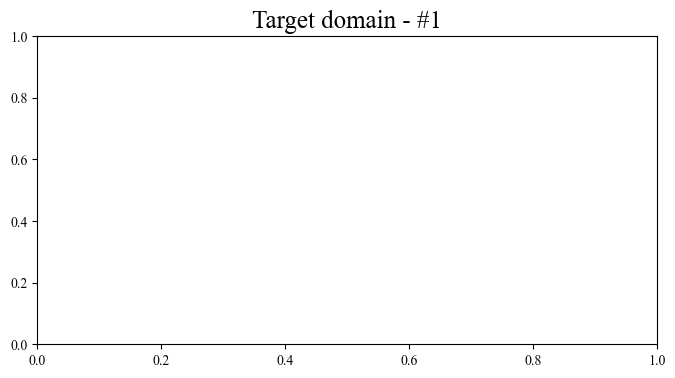

In [ ]:
Encoder.eval(); Predictor.eval()
monte_carlo= 30
### get target partial curve dataset
target_full_pack_dataset= real_csvfiles_in_folder(dataset_folder, TARGET_CELLS)
target_full_pack_dataset= data_smoothing(dataset= target_full_pack_dataset, lowess_tau= 1/5, verbose= False)
target_partial_pack_dataset= partial_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
# del target_full_pack_dataset
target_partial_before_pack_dataset= partial_before_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
target_partial_before_pack_dataset= target_partial_before_pack_dataset[target_partial_before_pack_dataset["battery_name"].isin([i.split(".")[0] for i in TARGET_CELLS])]
target_partial_before_pack_dataset, target_partial_before_cell_dataset_normalizer= data_normalization(dataset= target_partial_before_pack_dataset)
target_partial_before_pack_dataset= sliding_window_approach(dataset= target_partial_before_pack_dataset, m= sliding_window_size)
target_partial_after_pack_dataset= partial_after_dataset_generator(dataset= target_full_pack_dataset, Tsp_capacity= Tsp_capacity, window_size= sliding_window_size)
target_partial_after_pack_dataset= target_partial_after_pack_dataset[target_partial_after_pack_dataset["battery_name"].isin([i.split(".")[0] for i in TARGET_CELLS])]
target_partial_after_pack_dataset["charge_capacity"]= target_partial_before_cell_dataset_normalizer.transform(target_partial_after_pack_dataset[["charge_capacity"]])
target_partial_after_pack_dataset= sliding_window_approach(dataset= target_partial_after_pack_dataset, m= sliding_window_size)
for target_pack_name in target_pack_name_ls:
    target_partial_single_after_pack_dataset= target_partial_after_pack_dataset[target_partial_after_pack_dataset["cell"]== target_pack_name]
    target_partial_single_after_lstm_x, target_partial_single_after_lstm_y= train_dataset_generator(dataset= target_partial_single_after_pack_dataset, num_features= num_features)
    target_partial_single_after_lstm_x= torch.FloatTensor(target_partial_single_after_lstm_x).to(device)
    plt.figure(figsize= (8, 4))
    plt.title("Target domain - %s"%(target_pack_name), fontsize= 18)
    count= 0; predicted_RUL_ls= []
    actual_capacity= target_full_pack_dataset[target_full_pack_dataset["battery_name"]== target_pack_name]["Capacity"].values
    actual_capacity= actual_capacity[: np.where(actual_capacity<= EOL_capacity)[0][0]]
    Tsp= np.where(actual_capacity<= Tsp_capacity)[0][0]
    for simulation_i in range(0, monte_carlo):
        predicted_capacity= get_prediction(Encoder, Predictor, target_partial_single_after_lstm_x, target_partial_before_cell_dataset_normalizer)
        predicted_capacity= predicted_capacity.ravel()
        try:
            predicted_capacity= predicted_capacity[: np.where(predicted_capacity<= EOL_capacity)[0][0]]
            predicted_RUL_ls.append(len(predicted_capacity))
        except Exception as e:
            predicted_capacity= predicted_capacity
            predicted_RUL_ls.append(len(predicted_capacity))
        if count== 0: 
            plt.plot(np.arange(Tsp, Tsp+ len(predicted_capacity)), predicted_capacity, color= "darkblue", label= "predicted capacity", alpha= 0.7); count+= 1
        else: 
            plt.plot(np.arange(Tsp, Tsp+ len(predicted_capacity)), predicted_capacity, color= "darkblue", alpha= 0.7)
    actual_RUL= len(actual_capacity[np.where(actual_capacity>= Tsp_capacity)[0][-1]: ])
    predicted_RUL= [np.mean(predicted_RUL_ls)- 3* np.std(predicted_RUL_ls), np.mean(predicted_RUL_ls)+ 3* np.std(predicted_RUL_ls)]
    plt.plot(np.arange(0, len(actual_capacity)), actual_capacity, color= "black", label= "actual capacity")
    plt.hlines(Tsp_capacity, 0, max([len(actual_capacity), len(predicted_capacity)]), color= "darkorange", ls= "--", label= "Tsp")
    plt.hlines(EOL_capacity, 0, max([len(actual_capacity), len(predicted_capacity)]), color= "darkred", ls= "--", label= "EOL")
    plt.legend(loc= "best", fontsize= 15)
    plt.xlabel("cycles", fontsize= 15)
    plt.ylabel("capacity (mAh)", fontsize= 15)
    plt.xticks(fontsize= 12)
    plt.yticks(fontsize= 12)
    plt.show()
    print("Target domain capacity - %s// Actual RUL: %02d// Predicted RUL: [%2.4f, %2.4f]"%(target_pack_name, actual_RUL, predicted_RUL[0], predicted_RUL[1]))
    print("AE: %2.4f// RE: %2.4f"%(np.abs(actual_RUL- np.mean(predicted_RUL_ls)), np.abs(actual_RUL- np.mean(predicted_RUL_ls))/ actual_RUL))

NameError: name 'get_prediction' is not defined

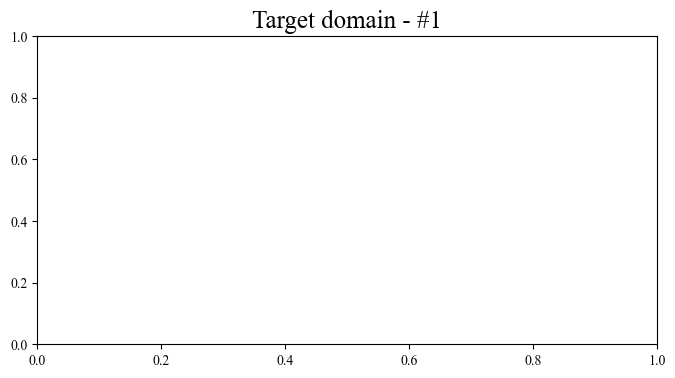

In [ ]:
for target_pack_name in target_pack_name_ls:
    target_partial_single_after_pack_dataset= target_partial_after_pack_dataset[target_partial_after_pack_dataset["cell"]== target_pack_name]
    target_partial_single_after_lstm_x, target_partial_single_after_lstm_y= train_dataset_generator(dataset= target_partial_single_after_pack_dataset, num_features= num_features)
    target_partial_single_after_lstm_x= torch.FloatTensor(target_partial_single_after_lstm_x).to(device)
    plt.figure(figsize= (8, 4))
    plt.title("Target domain - %s"%(target_pack_name), fontsize= 18)
    count= 0; predicted_RUL_ls= []
    actual_capacity= target_full_pack_dataset[target_full_pack_dataset["battery_name"]== target_pack_name]["charge_capacity"].values
    actual_capacity= actual_capacity[: np.where(actual_capacity<= EOL_capacity)[0][0]]
    Tsp= np.where(actual_capacity<= Tsp_capacity)[0][0]
    for simulation_i in range(0, monte_carlo):
        predicted_capacity= get_prediction(Encoder, Predictor, target_partial_single_after_lstm_x, target_partial_before_cell_dataset_normalizer)
        predicted_capacity= predicted_capacity.ravel()
        try:
            predicted_capacity= predicted_capacity[: np.where(predicted_capacity<= EOL_capacity)[0][0]]
            predicted_RUL_ls.append(len(predicted_capacity))
        except Exception as e:
            predicted_capacity= predicted_capacity
            predicted_RUL_ls.append(len(predicted_capacity))
        if count== 0: 
            plt.plot(np.arange(Tsp, Tsp+ len(predicted_capacity)), predicted_capacity, color= "darkblue", label= "predicted capacity", alpha= 0.7); count+= 1
        else: 
            plt.plot(np.arange(Tsp, Tsp+ len(predicted_capacity)), predicted_capacity, color= "darkblue", alpha= 0.7)
    actual_RUL= len(actual_capacity[np.where(actual_capacity>= Tsp_capacity)[0][-1]: ])
    predicted_RUL= [np.mean(predicted_RUL_ls)- 3* np.std(predicted_RUL_ls), np.mean(predicted_RUL_ls)+ 3* np.std(predicted_RUL_ls)]
    plt.plot(np.arange(0, len(actual_capacity)), actual_capacity, color= "black", label= "actual capacity")
    plt.hlines(Tsp_capacity, 0, max([len(actual_capacity), len(predicted_capacity)]), color= "darkorange", ls= "--", label= "Tsp")
    plt.hlines(EOL_capacity, 0, max([len(actual_capacity), len(predicted_capacity)]), color= "darkred", ls= "--", label= "EOL")
    plt.legend(loc= "best", fontsize= 15)
    plt.xlabel("cycles", fontsize= 15)
    plt.ylabel("capacity (mAh)", fontsize= 15)
    plt.xticks(fontsize= 12)
    plt.yticks(fontsize= 12)
    plt.show()
    print("Target domain capacity - %s// Actual RUL: %02d// Predicted RUL: [%2.4f, %2.4f]"%(target_pack_name, actual_RUL, predicted_RUL[0], predicted_RUL[1]))
    print("AE: %2.4f// RE: %2.4f"%(np.abs(actual_RUL- np.mean(predicted_RUL_ls)), np.abs(actual_RUL- np.mean(predicted_RUL_ls))/ actual_RUL))

In [ ]:
def get_prediction(encoder, predictor, x, normalizer):
    with torch.no_grad():
        pred_capacity_fade= predictor(encoder(x))
    pred_capacity_fade= pred_capacity_fade.data.cpu().numpy().ravel()
    x= x.data.cpu().numpy()
    predicted_capacity= pred_capacity_fade+ x[:, : , 0][:, -1]
    predicted_capacity= normalizer.inverse_transform(predicted_capacity.reshape(-1, 1))
    return predicted_capacity.ravel()

Time consuming (Training): 289621.8158 sec


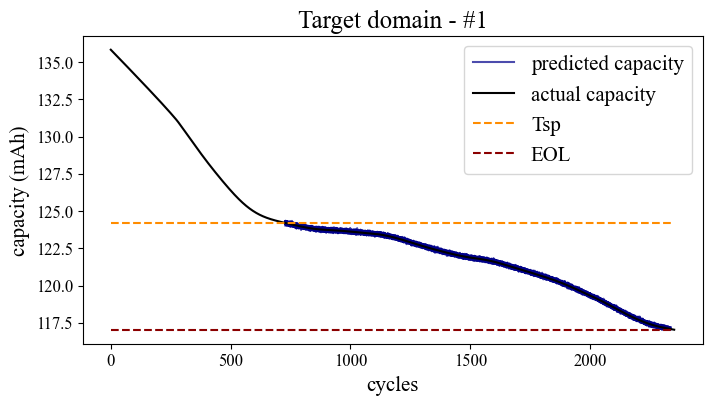

Target domain capacity - #1// Actual RUL: 1625// Predicted RUL: [1567.0496, 1625.6837]
AE: 28.6333// RE: 0.0176


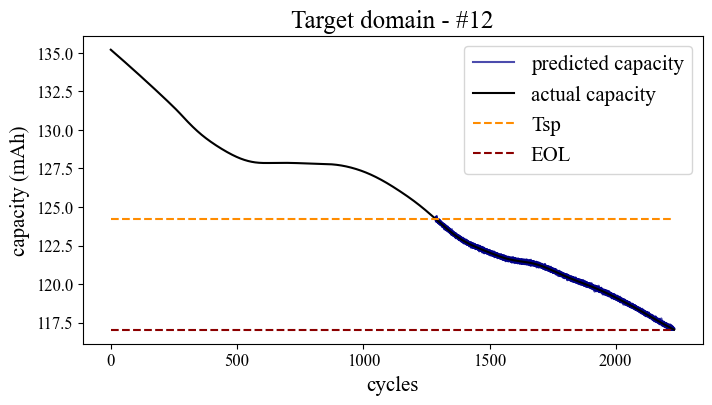

Target domain capacity - #12// Actual RUL: 945// Predicted RUL: [927.6750, 948.9250]
AE: 6.7000// RE: 0.0071


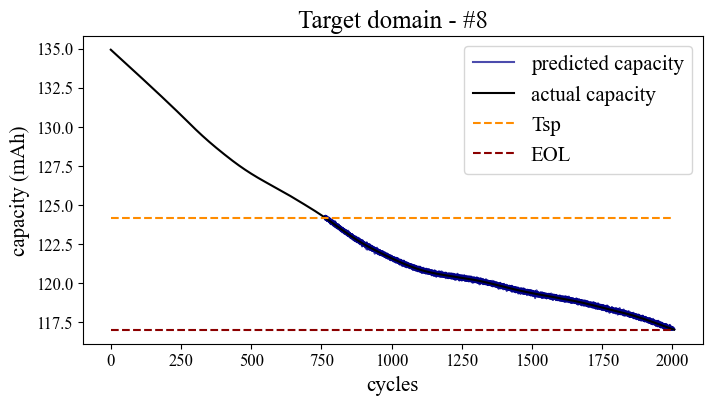

Target domain capacity - #8// Actual RUL: 1245// Predicted RUL: [1218.2466, 1250.6201]
AE: 10.5667// RE: 0.0085


In [ ]:
e_time= time.time()
print("Time consuming (Training): %05.4f sec"%(e_time- s_time))
Encoder.eval(); Predictor.eval()
monte_carlo= 30
### get target partial curve dataset
target_full_pack_dataset= real_csvfiles_in_folder(dataset_folder, TARGET_CELLS)
target_full_pack_dataset= data_smoothing(dataset= target_full_pack_dataset, lowess_tau= 1/5, verbose= False)
target_partial_pack_dataset= partial_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
# del target_full_pack_dataset
target_partial_before_pack_dataset= partial_before_dataset_generator(dataset= target_full_pack_dataset, Tsp= Tsp_capacity)
target_partial_before_pack_dataset= target_partial_before_pack_dataset[target_partial_before_pack_dataset["battery_name"].isin([i.split(".")[0] for i in TARGET_CELLS])]
target_partial_before_pack_dataset, target_partial_before_cell_dataset_normalizer= data_normalization(dataset= target_partial_before_pack_dataset)
target_partial_before_pack_dataset= sliding_window_approach(dataset= target_partial_before_pack_dataset, m= sliding_window_size)
target_partial_after_pack_dataset= partial_after_dataset_generator(dataset= target_full_pack_dataset, Tsp_capacity= Tsp_capacity, window_size= sliding_window_size)
target_partial_after_pack_dataset= target_partial_after_pack_dataset[target_partial_after_pack_dataset["battery_name"].isin([i.split(".")[0] for i in TARGET_CELLS])]
target_partial_after_pack_dataset["charge_capacity"]= target_partial_before_cell_dataset_normalizer.transform(target_partial_after_pack_dataset[["charge_capacity"]])
target_partial_after_pack_dataset= sliding_window_approach(dataset= target_partial_after_pack_dataset, m= sliding_window_size)
for target_pack_name in target_pack_name_ls:
    target_partial_single_after_pack_dataset= target_partial_after_pack_dataset[target_partial_after_pack_dataset["cell"]== target_pack_name]
    target_partial_single_after_lstm_x, target_partial_single_after_lstm_y= train_dataset_generator(dataset= target_partial_single_after_pack_dataset, num_features= num_features)
    target_partial_single_after_lstm_x= torch.FloatTensor(target_partial_single_after_lstm_x).to(device)
    plt.figure(figsize= (8, 4))
    plt.title("Target domain - %s"%(target_pack_name), fontsize= 18)
    count= 0; predicted_RUL_ls= []
    actual_capacity= target_full_pack_dataset[target_full_pack_dataset["battery_name"]== target_pack_name]["charge_capacity"].values
    actual_capacity= actual_capacity[: np.where(actual_capacity<= EOL_capacity)[0][0]]
    Tsp= np.where(actual_capacity<= Tsp_capacity)[0][0]
    for simulation_i in range(0, monte_carlo):
        predicted_capacity= get_prediction(Encoder, Predictor, target_partial_single_after_lstm_x, target_partial_before_cell_dataset_normalizer)
        predicted_capacity= predicted_capacity.ravel()
        try:
            predicted_capacity= predicted_capacity[: np.where(predicted_capacity<= EOL_capacity)[0][0]]
            predicted_RUL_ls.append(len(predicted_capacity))
        except Exception as e:
            predicted_capacity= predicted_capacity
            predicted_RUL_ls.append(len(predicted_capacity))
        if count== 0: 
            plt.plot(np.arange(Tsp, Tsp+ len(predicted_capacity)), predicted_capacity, color= "darkblue", label= "predicted capacity", alpha= 0.7); count+= 1
        else: 
            plt.plot(np.arange(Tsp, Tsp+ len(predicted_capacity)), predicted_capacity, color= "darkblue", alpha= 0.7)
    actual_RUL= len(actual_capacity[np.where(actual_capacity>= Tsp_capacity)[0][-1]: ])
    predicted_RUL= [np.mean(predicted_RUL_ls)- 3* np.std(predicted_RUL_ls), np.mean(predicted_RUL_ls)+ 3* np.std(predicted_RUL_ls)]
    plt.plot(np.arange(0, len(actual_capacity)), actual_capacity, color= "black", label= "actual capacity")
    plt.hlines(Tsp_capacity, 0, max([len(actual_capacity), len(predicted_capacity)]), color= "darkorange", ls= "--", label= "Tsp")
    plt.hlines(EOL_capacity, 0, max([len(actual_capacity), len(predicted_capacity)]), color= "darkred", ls= "--", label= "EOL")
    plt.legend(loc= "best", fontsize= 15)
    plt.xlabel("cycles", fontsize= 15)
    plt.ylabel("capacity (mAh)", fontsize= 15)
    plt.xticks(fontsize= 12)
    plt.yticks(fontsize= 12)
    plt.show()
    print("Target domain capacity - %s// Actual RUL: %02d// Predicted RUL: [%2.4f, %2.4f]"%(target_pack_name, actual_RUL, predicted_RUL[0], predicted_RUL[1]))
    print("AE: %2.4f// RE: %2.4f"%(np.abs(actual_RUL- np.mean(predicted_RUL_ls)), np.abs(actual_RUL- np.mean(predicted_RUL_ls))/ actual_RUL))